# RL Experiment Plots

Visualize training metrics from RL experiments across three settings:
- `real_world`
- `simulation`
- `simulation_with_real_world_input`

Metrics: `ep_len_mean`, `ep_rew_mean`, `top_score`

In [21]:
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import plot_learning_curves

import style
importlib.reload(style)
from style import MatplotlibStyle

mpl_style = MatplotlibStyle()
mpl_style.apply()

In [22]:
def read_rl_csv(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """
    Read an RL training CSV file by metric folder and file key.

    Args:
        metric:   subfolder name, e.g. "ep_len_mean", "ep_rew_mean", "top_score"
        key:      file stem, e.g. "real_world", "simulation",
                  "simulation_with_real_world_input"
        base_dir: root directory that contains the metric folders (default: ".")

    Returns:
        DataFrame with columns "Step" (x-axis) and "Value" (y-axis).
    """
    path = Path(base_dir) / metric / f"{key}.csv"
    df = pd.read_csv(path)
    return df[["Step", "Value"]].reset_index(drop=True)


def load_hns_scores(files_dict: dict, random_score: float, human_score: float) -> dict:
    """
    Load episode-score arrays from .npz files and convert to Human Normalized Score.

    Args:
        files_dict:   dict mapping label -> path to .npz file containing key 'array'.
        random_score: random-agent baseline score for the game.
        human_score:  human reference score for the game.

    Returns:
        dict mapping label -> 1-D numpy array of HNS values.
    """
    hns = {}
    for label, path in files_dict.items():
        raw = np.load(path)['array'].astype(float)
        hns[label] = (raw - random_score) / (human_score - random_score)
    return hns


In [23]:
def plot_rl_curves(
    data_dict,
    colors=None,
    legend_map=None,
    title="RL Learning Curves",
    x_label="Step",
    y_label="Value",
    y_lim=None,
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
    save_path=None,
    plot_raw=True,
    raw_alpha=0.35,
    raw_linewidth=0.7,
    smooth_linewidth=2,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_legend=None,
    fontsize_tick=None,
):
    """
    Plot RL training curves with optional rolling-average smoothing.
    Uses MatplotlibStyle settings (font, colors, tick sizes) applied globally.
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        data_dict:       dict mapping key -> DataFrame with "Step" and "Value" columns.
        colors:          list of line colors; if None, uses the style's prop_cycle colors.
        legend_map:      dict mapping key -> display label.
        y_lim:           (min, max) for y-axis, or None for auto.
        window_size:     rolling-average window (1 = no smoothing).
        save_path:       if given, saves figure as <save_path>.pdf.
        plot_raw:        overlay raw dashed trace under the smoothed line.
        fontsize_title:  title font size (default: rcParams axes.titlesize).
        fontsize_label:  x/y axis label font size (default: rcParams axes.labelsize).
        fontsize_legend: legend font size (default: rcParams legend.fontsize).
        fontsize_tick:   tick label font size (default: rcParams xtick/ytick.labelsize).
    """
    # Resolve font sizes from rcParams if not provided
    _title_fs  = fontsize_title  or plt.rcParams.get("axes.titlesize",  20)
    _label_fs  = fontsize_label  or plt.rcParams.get("axes.labelsize",  24)
    _legend_fs = fontsize_legend or plt.rcParams.get("legend.fontsize", 20)
    _tick_fs   = fontsize_tick   or plt.rcParams.get("xtick.labelsize", 20)

    # Resolve colors: use provided list, style prop_cycle, or a safe fallback
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple", "brown"]
    if len(colors) < len(data_dict):
        colors = [colors[i % len(colors)] for i in range(len(data_dict))]

    fig, ax = plt.subplots(figsize=figsize)

    for idx, (key, df) in enumerate(data_dict.items()):
        label = legend_map.get(key, str(key)) if legend_map else str(key)
        steps = df["Step"].values
        values = df["Value"].values
        color = colors[idx]

        if plot_raw:
            ax.plot(steps, values, linestyle="dashed", linewidth=raw_linewidth,
                    alpha=raw_alpha, color=color)

        if len(values) >= window_size:
            smoothed = pd.Series(values).rolling(window=window_size, min_periods=1).mean().values
            ax.plot(steps, smoothed, color=color, linewidth=smooth_linewidth, label=label)
        else:
            ax.plot(steps, values, color=color, linewidth=smooth_linewidth, label=label)

    if y_lim is not None:
        ax.set_ylim(y_lim)
    #ax.set_title(title, fontsize=_title_fs)
    ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    if is_legend:
        ax.legend(fontsize=_legend_fs)
    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

In [24]:
from scipy.stats import bootstrap as _scipy_bootstrap


# ── Helper statistics ────────────────────────────────────────────────────────
def _iqm(x):
    """Interquartile Mean: mean of scores in the [Q25, Q75] range."""
    q25, q75 = np.percentile(x, [25, 75])
    return np.mean(x[(x >= q25) & (x <= q75)])


def _bootstrap_ci(data, stat_fn, n_resamples=10_000, ci=0.95, seed=0):
    """Return (point_estimate, ci_low, ci_high) via percentile bootstrap."""
    result = _scipy_bootstrap(
        (data,), stat_fn,
        n_resamples=n_resamples,
        confidence_level=ci,
        method='percentile',
        random_state=seed,
    )
    return stat_fn(data), result.confidence_interval.low, result.confidence_interval.high


# ── Plotting function ────────────────────────────────────────────────────────
def plot_interval_estimates(
    hns_scores,
    metric='Median',
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    _STAT_FNS = {'Median': np.median, 'IQM': _iqm, 'Mean': np.mean}
    if metric not in _STAT_FNS:
        raise ValueError(f"metric must be one of {list(_STAT_FNS.keys())}, got '{metric}'")
    stat_fn = _STAT_FNS[metric]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  13)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 11)

    _DEFAULT_COLOURS = {
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        data = hns_scores[label]
        pt, lo, hi = _bootstrap_ci(data, stat_fn, n_resamples=n_resamples, ci=ci)
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    ax.set_yticks(range(len(system_order)))
    ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.pdf', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


## Episode Length Mean (`ep_len_mean`)

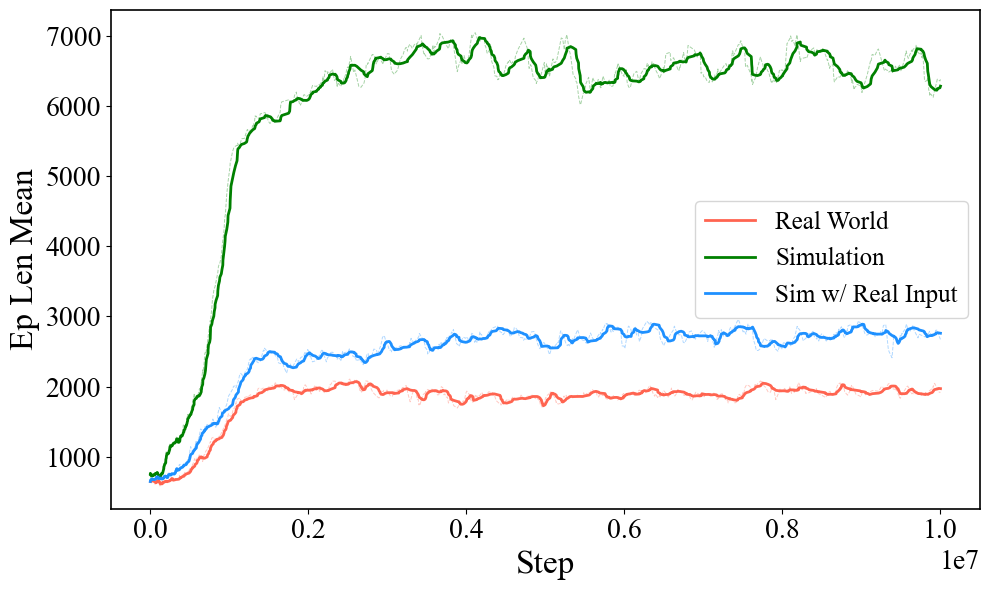

In [25]:
keys = ["real_world", "simulation", "simulation_with_real_world_input"]
legend_map = {
    "real_world": "Real World",
    "simulation": "Simulation",
    "simulation_with_real_world_input": "Sim w/ Real Input",
}

data_ep_len = {key: read_rl_csv("ep_len_mean", key) for key in keys}

plot_rl_curves(
    data_ep_len,
    legend_map=legend_map,
    title="Episode Length Mean",
    x_label="Step",
    y_label="Ep Len Mean",
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
)

## Episode Reward Mean (`ep_rew_mean`)

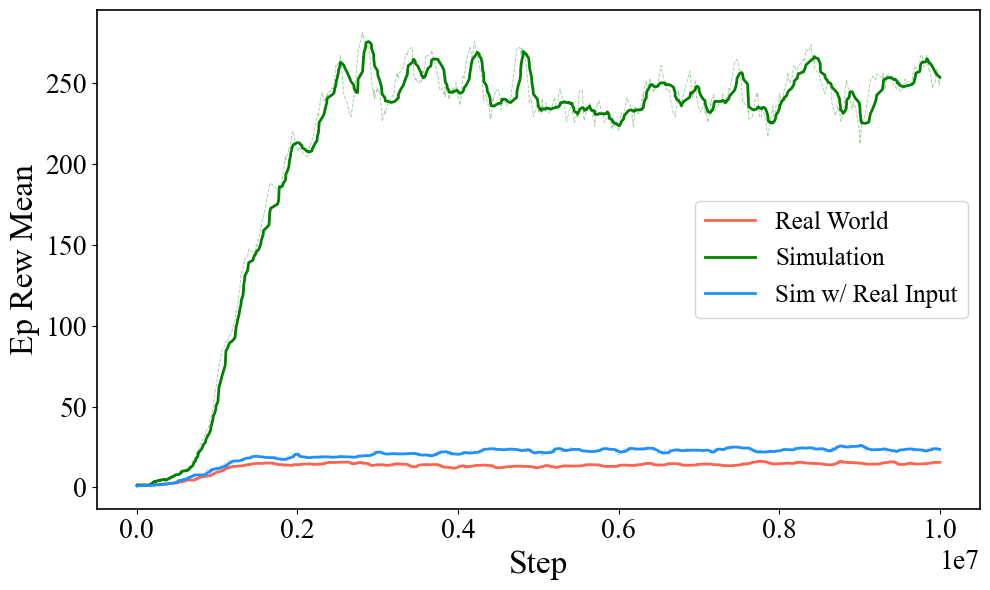

In [26]:
data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    title="Episode Reward Mean",
    x_label="Step",
    y_label="Ep Rew Mean",
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
)

## Top Score (`top_score`)

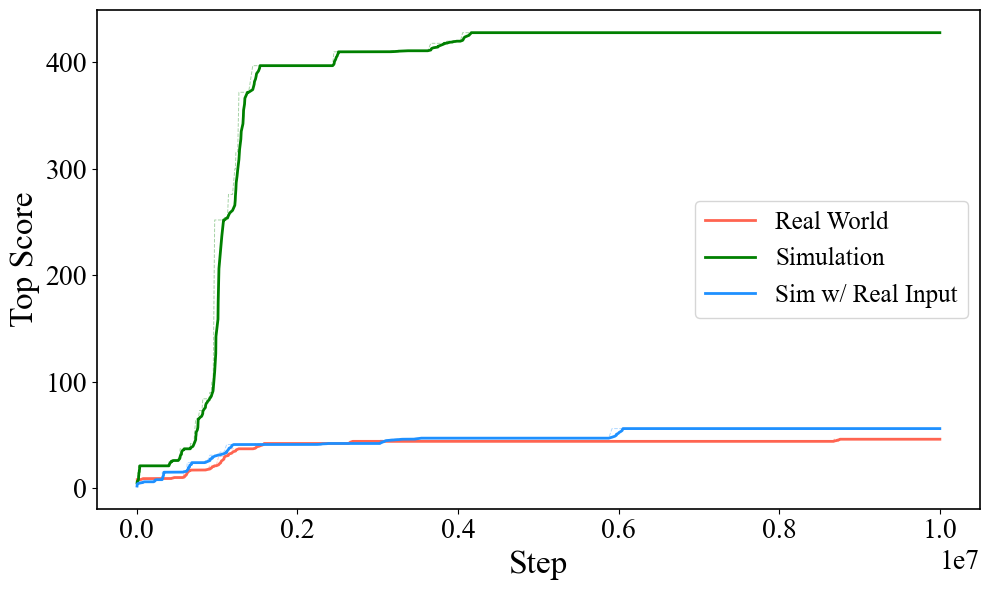

In [27]:
data_top_score = {key: read_rl_csv("top_score", key) for key in keys}

plot_rl_curves(
    data_top_score,
    legend_map=legend_map,
    title="Top Score",
    x_label="Step",
    y_label="Top Score",
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
)

## Time Cost Comparison (Bar Chart)

Compare the **total wall-clock time consumed** by each setting across equal-length step intervals.

In [28]:
def read_rl_csv_full(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """Read RL CSV with Wall time, Step, Value columns."""
    path = Path(base_dir) / metric / f"{key}.csv"
    df = pd.read_csv(path)
    return df[["Wall time", "Step", "Value"]].reset_index(drop=True)


def plot_time_cost_bar(
    metric: str = "ep_len_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    x_label: str = "Time Cost (s)",
    y_label: str = "",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    if keys is None:
        keys = ["real_world", "simulation", "simulation_with_real_world_input"]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    total_times = {}
    for key in keys:
        df = read_rl_csv_full(metric, key, base_dir)
        total_times[key] = df["Wall time"].max() - df["Wall time"].min()

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]

    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    values = [total_times[k] for k in keys]
    bar_colors = [colors[i % len(colors)] for i in range(len(keys))]

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(labels, values, color=bar_colors, edgecolor="white", linewidth=0.5)

    ax.set_title(title, fontsize=_title_fs)
    ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)

    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()


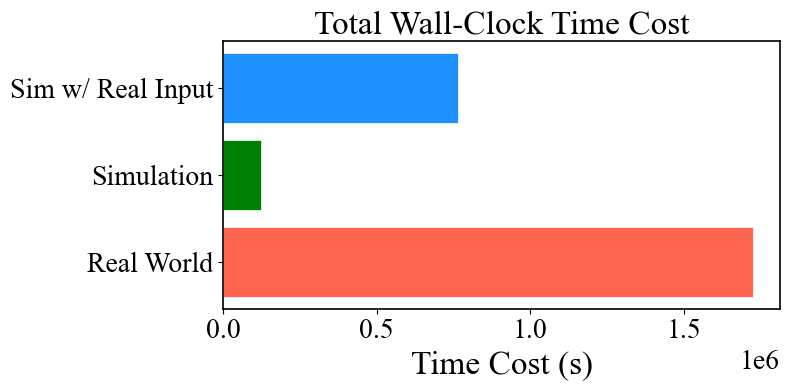

In [29]:
plot_time_cost_bar(
    metric="ep_len_mean",
    keys=["real_world", "simulation", "simulation_with_real_world_input"],
    legend_map=legend_map,
    base_dir=".",
    title="Total Wall-Clock Time Cost",
    x_label="Time Cost (s)",
    figsize=(8, 4),
    save_path="time_cost_bar",
)


## Three Systems Comparison — Interval Estimates (Median / IQM / Mean)

In [30]:
# Breakout: random ≈ 1.7, human ≈ 30.5
RANDOM_SCORE = 1.7
HUMAN_SCORE  = 30.5

_3systems_files = {
    'real world system': './datalogs/3systems/breakout-data-dqn-model-r10_000_000.npz',
    'real world input':  './datalogs/3systems/breakout-data-dqn-model-c10_000_000.npz',
    'simulation':        './datalogs/3systems/breakout-data-dqn-model-s10_000_000.npz',
}

hns_scores = load_hns_scores(_3systems_files, RANDOM_SCORE, HUMAN_SCORE)

for lbl, arr in hns_scores.items():
    print(f"{lbl:25s}: n={len(arr):3d}  mean={arr.mean():.3f}  median={np.median(arr):.3f}")


real world system        : n=100  mean=0.426  median=0.410
real world input         : n=101  mean=0.752  median=0.705
simulation               : n=101  mean=8.389  median=9.212


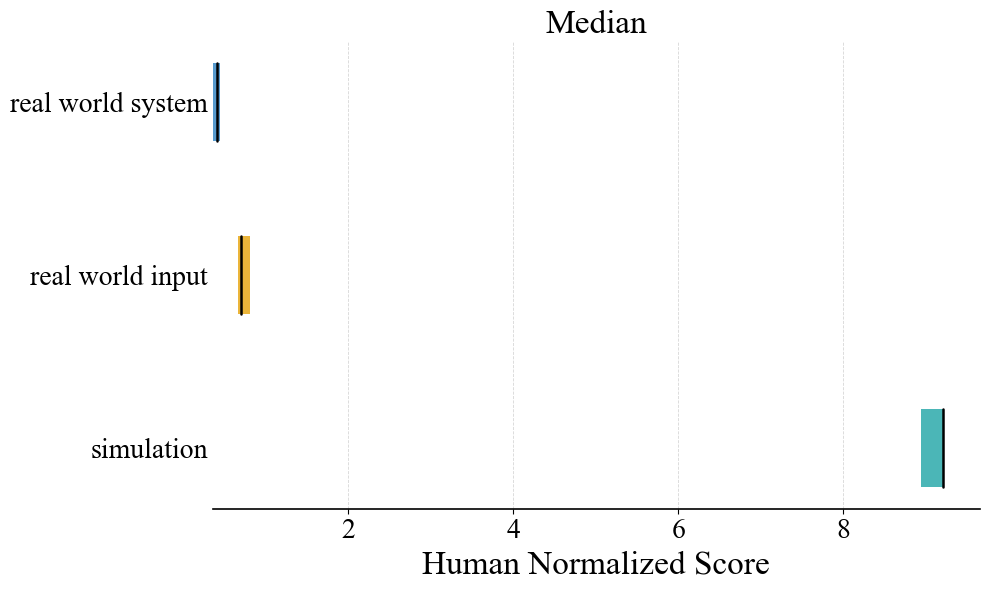

In [31]:
SYSTEM_ORDER = ['simulation', 'real world input', 'real world system']

plot_interval_estimates(
    hns_scores,
    metric='Median',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_median',
)


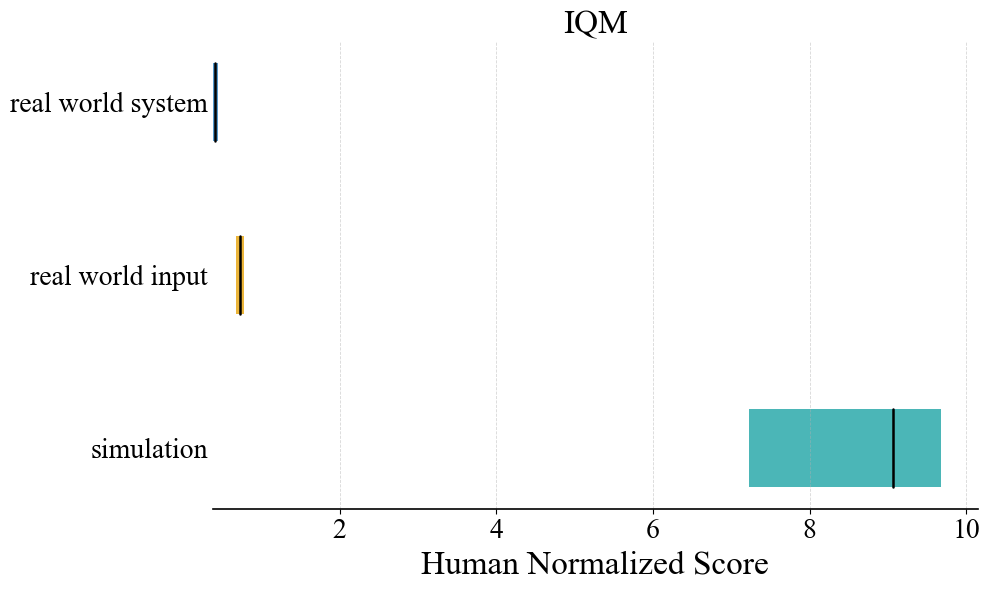

In [32]:
plot_interval_estimates(
    hns_scores,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_iqm',
)


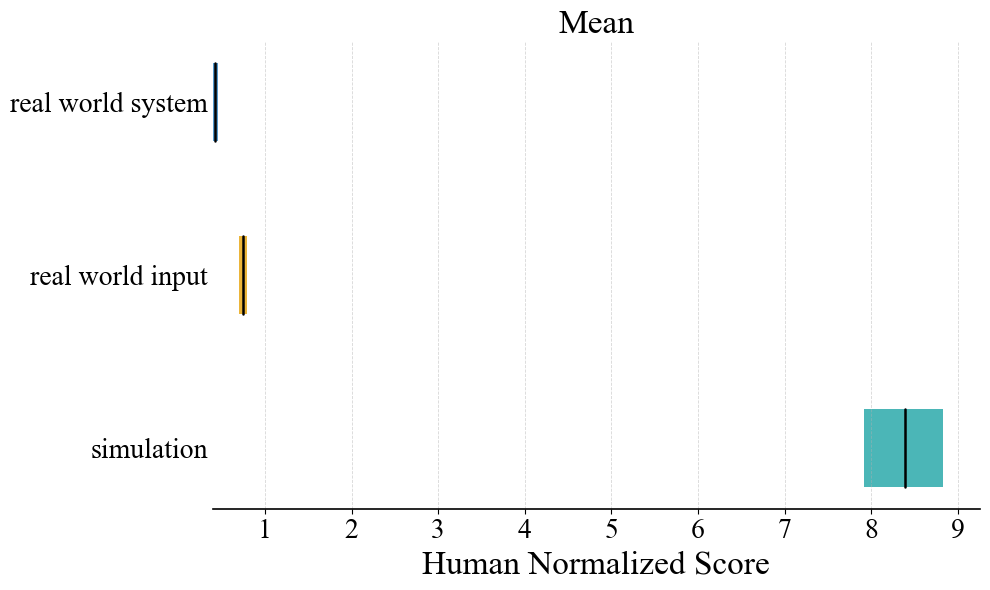

In [33]:
plot_interval_estimates(
    hns_scores,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_mean',
)
